In [1]:
import os 
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('/Users/wangshuaibo/Downloads/跑步数据240508.xls')
df.columns

Index(['id', 'user_id', 'sport_type', 'start_time', 'sport_duration_s',
       'sport_duration_min', 'total_distance_m', 'total_distance_km',
       'km_pace_average_s', 'km_pace_average_min', 'km_pace_fast_s',
       'km_pace_fast_min', 'gender', 'age', 'height_m', 'weight_kg', 'bmi'],
      dtype='object')

## 分析最常跑步的跑者时段

In [19]:
import pandas as pd

# 假设你的数据已经加载到一个名为df的DataFrame中，并且'start_time'列已经存在
# 确保'start_time'列的时间格式是正确的日期时间格式
# 如果不是，可以使用pd.to_datetime转换
df['start_time'] = pd.to_datetime(df['start_time'])

# 提取小时数
df['hour'] = df['start_time'].dt.hour

# 计算每小时的数据总数
hourly_counts = df['hour'].value_counts().sort_index()

# 计算总的记录数
total_counts = len(df)

# 计算每小时的百分比
hourly_counts_percentage = (hourly_counts / total_counts) * 100

# 输出每小时的数据总数和百分比
#print("每小时的数据总数：")
#print(hourly_counts)
#print("\n每小时数据的百分比：")
#print(hourly_counts_percentage)

# 如果需要，可以将结果保存到新的DataFrame中
hourly_analysis_df = pd.DataFrame({
    'hour': hourly_counts.index,
    'count': hourly_counts.values,
    'percentage': hourly_counts_percentage.values
})

# 显示结果
print(hourly_analysis_df)

    hour  count  percentage
0      0     73    0.362103
1      1     48    0.238095
2      2     34    0.168651
3      3     99    0.491071
4      4    195    0.967262
5      5    800    3.968254
6      6   1990    9.871032
7      7   1891    9.379960
8      8   1216    6.031746
9      9    871    4.320437
10    10    837    4.151786
11    11    762    3.779762
12    12    684    3.392857
13    13    578    2.867063
14    14    552    2.738095
15    15    748    3.710317
16    16   1178    5.843254
17    17   2099   10.411706
18    18   2403   11.919643
19    19   1526    7.569444
20    20    806    3.998016
21    21    393    1.949405
22    22    228    1.130952
23    23    149    0.739087


In [ ]:
plt.rcParams['font.sans-serif'] = ['Heiti TC']
plt.rcParams['font.family'] = ['Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

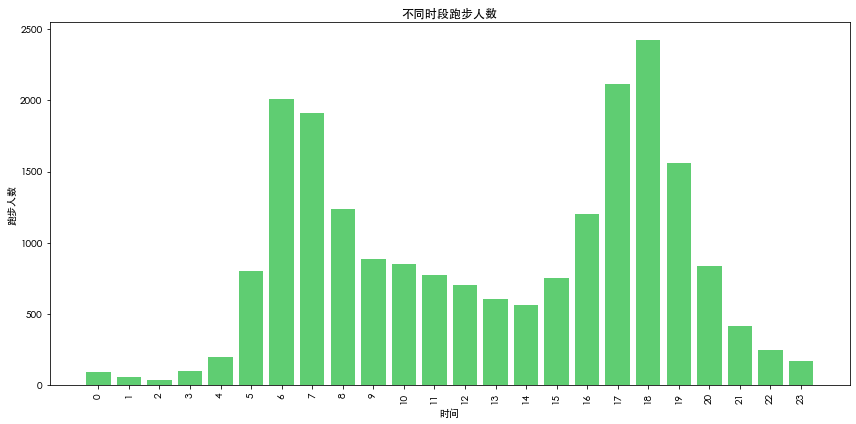

In [10]:


# 绘制柱状图
plt.figure(figsize=(12, 6))  # 设置图形的大小
plt.bar(hourly_counts.index, hourly_counts.values, color='#5fcd72')  # 创建柱状图
plt.xlabel('时间')  # x轴标签
plt.ylabel('跑步人数')  # y轴标签
plt.title('不同时段跑步人数')  # 图形标题
plt.xticks(range(24), rotation=90)  # 设置x轴的刻度和旋转，以便更好地显示小时数

# 显示图形
plt.tight_layout()  # 调整布局以适应标签
plt.show()

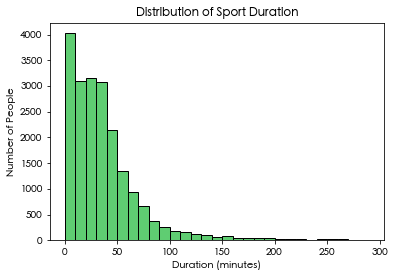

In [18]:


# 过滤异常值
df = df[df['sport_duration_min'] <= 300]

# 划分时间段
bins = list(range(0, 300, 10))

# 创建直方图
plt.hist(df['sport_duration_min'], bins=bins, edgecolor='black', color='#5fcd72')

# 添加标题和标签
plt.title('Distribution of Sport Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of People')

# 显示图形
plt.show()


## 跑者的常见距离

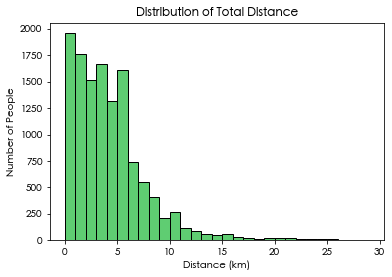

In [54]:


# 过滤异常值
df = df[df['sport_duration_min'] <= 300]

# 划分时间段
bins = list(range(0, 30, 1))

# 创建直方图
plt.hist(df['total_distance_km'], bins=bins, edgecolor='black', color='#5fcd72')

# 添加标题和标签
plt.title('Distribution of Total Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Number of People')

# 显示图形
plt.show()


# 不同配速人群占比

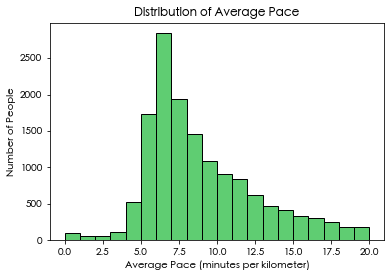

In [20]:
# 过滤异常值
df = df[(df['sport_duration_min'] <= 400) & (df['km_pace_average_min'] <= 20)]

# 划分时间段
bins = list(range(0, 21, 1))

# 创建直方图
plt.hist(df['km_pace_average_min'], bins=bins, edgecolor='black', color='#5fcd72')

# 添加标题和标签
plt.title('Distribution of Average Pace')
plt.xlabel('Average Pace (minutes per kilometer)')
plt.ylabel('Number of People')

# 显示图形
plt.show()

# 最快配速分配人群

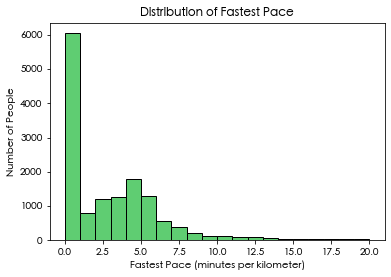

In [21]:

# 过滤异常值
df = df[(df['sport_duration_min'] <= 400) & (df['km_pace_fast_min'] <= 20)]

# 划分时间段
bins = list(range(0, 21, 1))

# 创建直方图
plt.hist(df['km_pace_fast_min'], bins=bins, edgecolor='black', color='#5fcd72')

# 添加标题和标签
plt.title('Distribution of Fastest Pace')
plt.xlabel('Fastest Pace (minutes per kilometer)')
plt.ylabel('Number of People')

# 显示图形
plt.show()


# 不同年龄段人群占比

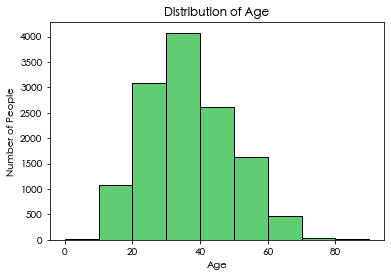

In [22]:


# 过滤异常值
df = df[(df['sport_duration_min'] <= 400) & 
        (df['km_pace_average_min'] <= 20) & 
        (df['km_pace_fast_min'] <= 20)]

# 划分年龄段
bins = list(range(0, int(df['age'].max()) + 11, 10))

# 创建直方图
plt.hist(df['age'], bins=bins, edgecolor='black', color='#5fcd72')

# 添加标题和标签
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Number of People')

# 显示图形
plt.show()


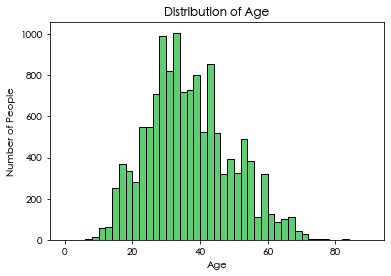

In [23]:
# 过滤异常值
df = df[(df['sport_duration_min'] <= 400) & 
        (df['km_pace_average_min'] <= 20) & 
        (df['km_pace_fast_min'] <= 20)]

# 划分年龄段（每 2 岁为一个区间）
bins = list(range(0, int(df['age'].max()) + 3, 2))

# 创建直方图
plt.hist(df['age'], bins=bins, edgecolor='black', color='#5fcd72')

# 添加标题和标签
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Number of People')

# 显示图形
plt.show()

## 不同跑者身高分布

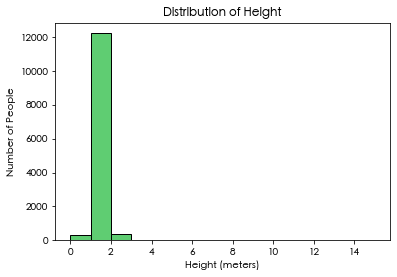

In [30]:
# 过滤异常值
df = df[(df['sport_duration_min'] <= 400) & 
        (df['km_pace_average_min'] <= 20) & 
        (df['km_pace_fast_min'] <= 20)]

# 划分身高段（每 0.5 米为一个区间）
bins = list(range(0, int(df['height_m'].max() * 5) + 1, 1))

# 创建直方图
plt.hist(df['height_m'], bins=bins, edgecolor='black', color='#5fcd72')

# 添加标题和标签
plt.title('Distribution of Height')
plt.xlabel('Height (meters)')
plt.ylabel('Number of People')

# 显示图形
plt.show()

# 分析体重

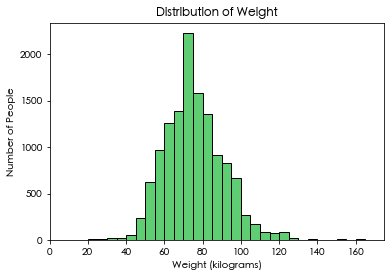

In [34]:
# 过滤异常值
df = df[(df['sport_duration_min'] <= 400) & 
        (df['km_pace_average_min'] <= 20) & 
        (df['km_pace_fast_min'] <= 20) &
        (df['height_m'] >= 0) &   # 过滤掉负数身高
        (df['weight_kg'] >= 0)]    # 过滤掉负数体重

# 划分体重段（每 5 公斤为一个区间）
bins = list(range(0, 176, 5))

# 创建直方图
plt.hist(df['weight_kg'], bins=bins, edgecolor='black', color='#5fcd72')

# 设置横坐标范围
plt.xlim(0, 175)

# 添加标题和标签
plt.title('Distribution of Weight')
plt.xlabel('Weight (kilograms)')
plt.ylabel('Number of People')

# 显示图形
plt.show()

# 绘制 BMI 情况

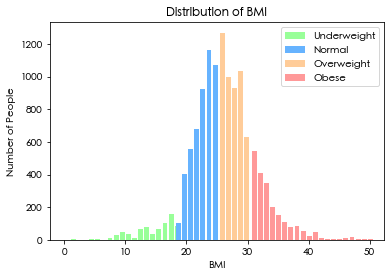

In [41]:
# 过滤异常值
df = df[(df['sport_duration_min'] <= 400) & 
        (df['km_pace_average_min'] <= 20) & 
        (df['km_pace_fast_min'] <= 20) &
        (df['height_m'] >= 0) &   # 过滤掉负数身高
        (df['weight_kg'] >= 0) &  # 过滤掉负数体重
        (df['bmi'] >= 0) &        # 过滤掉负数 BMI
        (df['bmi'] <= 50)]        # 过滤掉超大 BMI

# 划分 BMI 段（每 1 为一个区间）
bins = list(range(0, int(df['bmi'].max()) + 2, 1))

# 根据 BMI 的范围将数据分组
underweight = df[df['bmi'] < 18.5]['bmi']
normal = df[(df['bmi'] >= 18.5) & (df['bmi'] < 25)]['bmi']
overweight = df[(df['bmi'] >= 25) & (df['bmi'] < 30)]['bmi']
obese = df[df['bmi'] >= 30]['bmi']

# 定义颜色
colors = ['#99ff99', '#66b3ff', '#ffcc99', '#ff9999']

# 创建直方图，调整柱子宽度
plt.hist([underweight, normal, overweight, obese], bins=bins, color=colors, 
         width=0.8)

# 添加标题和标签
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Number of People')

# 添加图例
plt.legend(['Underweight', 'Normal', 'Overweight', 'Obese'])

# 显示图形
plt.show()

# 不同跑步类型比例

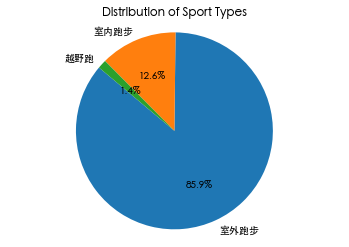

In [42]:
# 过滤异常值
df = df[(df['sport_duration_min'] <= 400) & 
        (df['km_pace_average_min'] <= 20) & 
        (df['km_pace_fast_min'] <= 20) &
        (df['height_m'] >= 0) &   # 过滤掉负数身高
        (df['weight_kg'] >= 0) &  # 过滤掉负数体重
        (df['bmi'] >= 0)]         # 过滤掉负数 BMI

# 统计不同跑步类型的数量
sport_type_counts = df['sport_type'].value_counts()

# 绘制饼状图
plt.pie(sport_type_counts, labels=sport_type_counts.index, autopct='%1.1f%%', startangle=140)

# 添加标题
plt.title('Distribution of Sport Types')

# 显示图形
plt.axis('equal')  # 保持圆形
plt.show()

# 统计男女比例

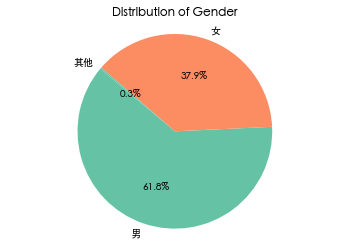

In [43]:
# 统计男女比例
gender_counts = df['gender'].value_counts()

# 绘制饼状图
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66c2a5', '#fc8d62'])

# 添加标题
plt.title('Distribution of Gender')

# 显示图形
plt.axis('equal')  # 保持圆形
plt.show()

## 重复用户分析

In [44]:
# 找出重复的用户
duplicate_users = df[df.duplicated(subset=['user_id'], keep=False)]

# 统计重复用户的数量
duplicate_users_count = duplicate_users['user_id'].nunique()

print("重复用户的数量:", duplicate_users_count)

重复用户的数量: 1637


In [57]:
# 计算总用户数量
total_users_count = df['user_id'].nunique()

# 计算重复用户数量
duplicate_users_count = duplicate_users['user_id'].nunique()

# 计算重复用户占所有用户的比例
duplicate_users_ratio = duplicate_users_count / total_users_count

# 统计重复用户的训练总次数
total_trainings_count = len(duplicate_users)

print("重复用户数量:", duplicate_users_count)
print("重复用户占所有用户的比例:", duplicate_users_ratio)
print("重复用户的训练总次数:", total_trainings_count)


重复用户数量: 1637
重复用户占所有用户的比例: 0.525521669341894
重复用户的训练总次数: 11124


In [49]:
total_users_count = df['user_id'].nunique()
total_users_count

3115

## 重复用户经常跑步的距离

In [ ]:


# 过滤异常值
df = df[df['sport_duration_min'] <= 300]

# 划分时间段
bins = list(range(0, 30, 1))

# 创建直方图
plt.hist(df['total_distance_km'], bins=bins, edgecolor='black', color='#5fcd72')

# 添加标题和标签
plt.title('Distribution of Total Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Number of People')

# 显示图形
plt.show()


# 回收站

## 查看不同跑步时长的分布

### kimi 给的代码没有办法运行

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设df是包含数据的DataFrame

# 将sport_duration_min转换为整数
df['sport_duration_min'] = df['sport_duration_min'].astype(int)

# 使用cut函数将运动时长分为每10分钟一个区间
duration_bins = range(0, 121, 10)  # 从0到120分钟，每10分钟一个区间
df['duration_group'] = pd.cut(df['sport_duration_min'], bins=duration_bins, include_lowest=True, right=False)

# 计算每个区间的人数
duration_counts = df['duration_group'].value_counts()

# 计算总人数
total_runs = len(df)

# 计算每个区间的人数占比
duration_percentage = (duration_counts / total_runs) * 100

# 获取区间的中点作为x轴的刻度
duration_centers = [(a + b) // 2 for a, b in zip(duration_bins[:-1], duration_bins[1:])] + [duration_bins[-1]]

# 由于我们是以10分钟为单位，所以直接使用duration_centers作为标签
duration_labels = [f'{c}-' for c in duration_centers[:-1]] + [f'{duration_centers[-1]}+']

# 绘制柱状图
plt.figure(figsize=(12, 6))
plt.bar(duration_centers, duration_percentage, color='#5fcd72')  # 设置柱状图颜色
plt.xlabel('Sport Duration (10-minute bins)')
plt.ylabel('Percentage of Runs')
plt.title('Percentage of Runs by Duration in 10-minute Bins')

# 设置x轴的刻度标签
plt.xticks(duration_centers[:-1], labels=duration_labels)

# 显示图形
plt.tight_layout()
plt.show()

### chatGPT 给的没有调试前的代码

In [ ]:


# 划分时间段
bins = list(range(0, int(df['sport_duration_min'].max()) + 11, 10))

# 创建直方图
plt.hist(df['sport_duration_min'], bins=bins, edgecolor='black',color='#5fcd72')

# 添加标题和标签
plt.title('Distribution of Sport Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of People')

# 显示图形
plt.show()
